# PSMILES

In [2]:
!pip install 'psmiles[polyBERT,mordred]@git+https://github.com/Ramprasad-Group/psmiles.git'

  Cloning https://github.com/Ramprasad-Group/psmiles.git to /private/var/folders/hw/c4dxvyzs2qb95867vr1393n80000gn/T/pip-install-wz8h5943/psmiles_e14a3ccbf29b4964a814be2ac39ccce4
  Running command git clone --filter=blob:none --quiet https://github.com/Ramprasad-Group/psmiles.git /private/var/folders/hw/c4dxvyzs2qb95867vr1393n80000gn/T/pip-install-wz8h5943/psmiles_e14a3ccbf29b4964a814be2ac39ccce4
  Resolved https://github.com/Ramprasad-Group/psmiles.git to commit 806b8dacc3c7d801bcfad74ff505b3c4b23db912
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/Ramprasad-Group/canonicalize_psmiles.git to /private/var/folders/hw/c4dxvyzs2qb95867vr1393n80000gn/T/pip-install-wz8h5943/canonicalize-psmiles_7902c4af55084290b79155142e547469
  Running command git clone --filter=blob:none --quiet https://github.com/Ramprasad-Group/canonicalize_psmiles.git /private/var/folders/hw/c4dxvyzs2qb9

In [21]:
from psmiles import PolymerSmiles as PS
ps = PS('[*]NC(C)CC([*])=O')
ps

AssertionError: PSMILES strings must have two [*], two *, [e] and [t], or [d] and [g] : [*]C(=O)N[*][*]CC(=O)O[*

[*]c1cccc([*])c1


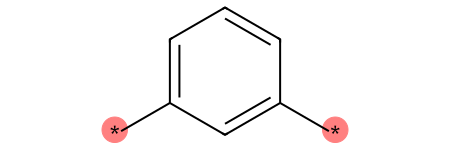

In [8]:
# Canonicalize the PSMILES string.
ps.canonicalize

In [9]:
# Save the figure to disk. Default name to PSMILES string.
ps.canonicalize.savefig()

[*]c1cc([*])ccc1


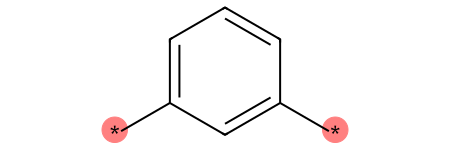

c1([*])cccc(c1)[*]


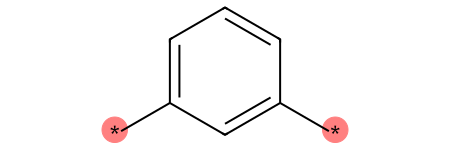

[*]c1cc([*])ccc1


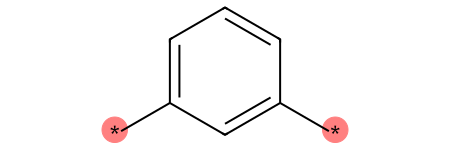

In [10]:
# Randomize the PSMILES string (chemistry is preserved)
_ = [display(ps.randomize) for _ in range(3)]

In [ ]:
# First randomize then canonicalize the PSMILES strings. The PSMILES strings are the same.
pss = [ps.randomize.canonicalize for _ in range(3)]
[display(_ps) for _ps in pss]
assert len(set([str(_ps) for _ps in pss])) == 1

In [ ]:
# Get the dimer from the monomer. 
# Connect to first star
ps.dimer(0)

In [ ]:
# Connect to second star
ps.dimer(1)

### Fingerprints for PSMILES strings

In [ ]:
# CI fingerprint
ps.fingerprint('ci')

In [ ]:
# Mordred fingerprint
# print only the first 10 fingerprints
{k:v for k,v in [x for x in ps.fingerprint('mordred').items()][:10]}


In [ ]:
ps.fingerprint('rdkit')

In [ ]:
# polyBERT fingerprint. 
# polyBERT is a chemical language model that has learned to predict PSMILES string fingerprints.
# polyBERT is super fast
ps.fingerprint('polyBERT')

### Canonicalize PSMILES 

set `logging.getLogger().setLevel(logging.DEBUG)` for verbose mode


In [13]:
# add draw options
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.drawOptions.addBondIndices= False
IPythonConsole.drawOptions.minFontSize = 16
IPythonConsole.molSize = (600, 200)   # Change image size
IPythonConsole.ipython_useSVG = True  # Change output to SVG

In [ ]:
import logging
# The INFO level does not give any additional information
logging.getLogger().setLevel(logging.INFO)
sm = '[*]NC(C)CC([*])=O'
display(PS(sm))
display(PS(sm).canonicalize)

In [ ]:
import logging
# The DEBUG level visualizes the canonicalization process  
logging.getLogger().setLevel(logging.DEBUG)
sm = '[*]NC(C)CC([*])=O'
display(PS(sm))
display(PS(sm).canonicalize)

### Inchi string and inchi key of PSMILES string

In [ ]:
logging.getLogger().setLevel(logging.INFO)
ps.inchi

In [ ]:
ps.inchi_key

###  Alternating copolymers from two PSMILES strings
The second argument of the function alternating_copolymer specifies which how the *s are connected

[*]C(=O)NCC(=O)NC(=O)CC([*])(C)C(=O)Oc1cccc(C)c1C


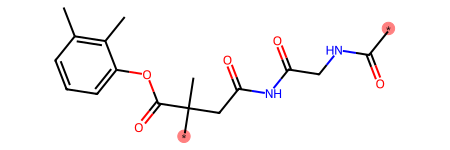

In [20]:
ps1 = PS('C(C([*])(C([*]))C)(=O)OC1=C(C(=CC=C1)C)C')
ps2 = PS('[*]C(=O)NCC(=O)NC(=O)[*]')
ps1.alternating_copolymer(ps2, [1,1])

[*]CC(C)(C(=O)NC(=O)CNC([*])=O)C(=O)Oc1cccc(C)c1C


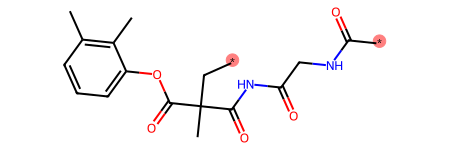

In [16]:
ps1.alternating_copolymer(ps2, [0,1])

[*]OCCCC([*])(C)C(=O)Oc1cccc(C)c1C


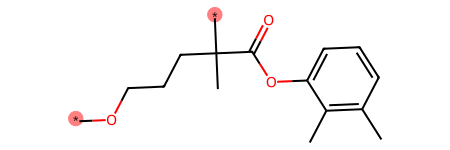

In [14]:
ps1.alternating_copolymer(ps2, [1,0])

In [ ]:
ps1.alternating_copolymer(ps2, [1,1])